<a href="https://colab.research.google.com/github/AngelKociankowski/MIA/blob/MIA1/MNA_IAyAA_Actividad_Pronosticos_Series_de_Tiempo_A01379225.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Inteligencia Artificial y Aprendizaje Automático**
## **Maestría en Inteligencia Artificial Aplicada**
### **Dr Luis Eduardo Falcón Morales**
### **Tecnológico de Monterrey**
## **Actividad Individual Semana 9: Pronósticos con Series de Tiempo**


#### **Nombre:** Angel Sebastian Kociankowski Montelongo
#### **Matrícula:** A01379225

Modelos para predicción de un problema de serie de tiempo:

* **1. Modelo ingenuo**
* **2. Modelo ARIMA**
* **3. Modelo Prophet**
* **4. Modelo LSTM**

In [ ]:
## ++++++++++ Incluye todas las celdas y líneas de código que requieras +++++++++++++++++++++++++


Preparación de datos

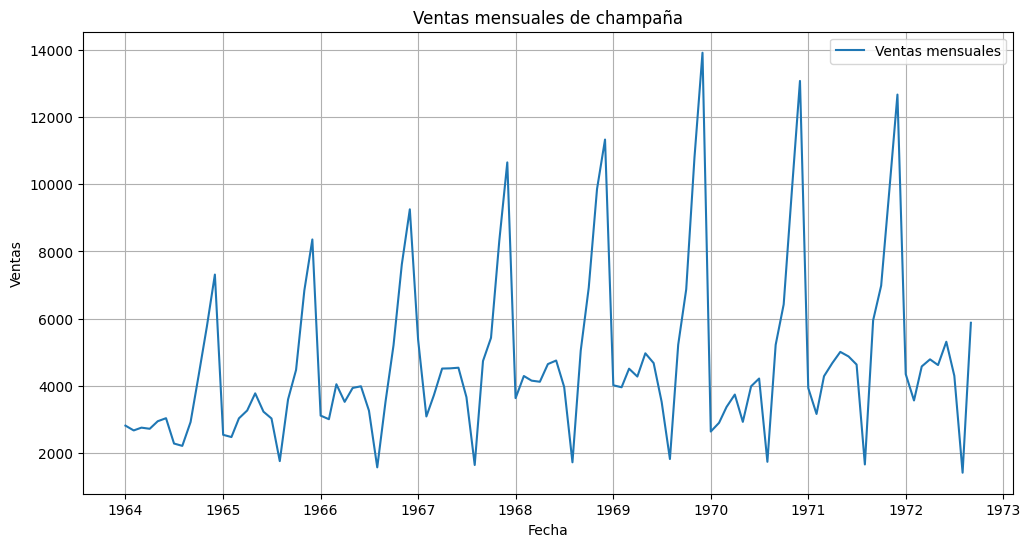

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error
from math import sqrt
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
import matplotlib.pyplot as plt
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping

# Cargar datos
df = pd.read_csv("monthly_champagne_sales.csv")
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# Visualización
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Sales'], label="Ventas mensuales")
plt.title("Ventas mensuales de champaña")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.grid(True)
plt.legend()
plt.show()


Modelo Ingenuo

Naive RMSE: 2638.3566454256215


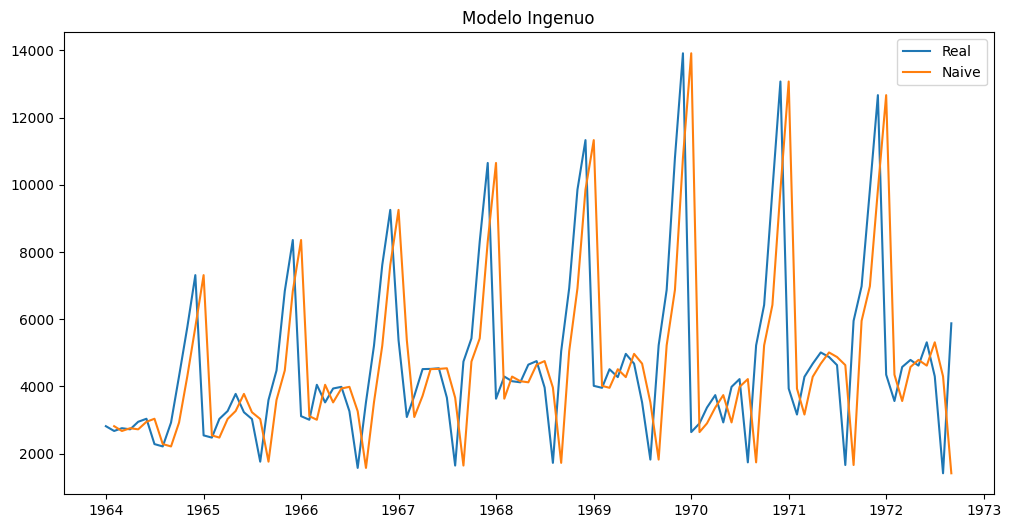

In [6]:
df['Naive'] = df['Sales'].shift(1)

naive_rmse = sqrt(mean_squared_error(df['Sales'][1:], df['Naive'][1:]))
print("Naive RMSE:", naive_rmse)

plt.figure(figsize=(12, 6))
plt.plot(df['Sales'], label='Real')
plt.plot(df['Naive'], label='Naive')
plt.title("Modelo Ingenuo")
plt.legend()
plt.show()


In [ ]:
Modelo ARIMA

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


ARIMA RMSE: 1824.0174166986171


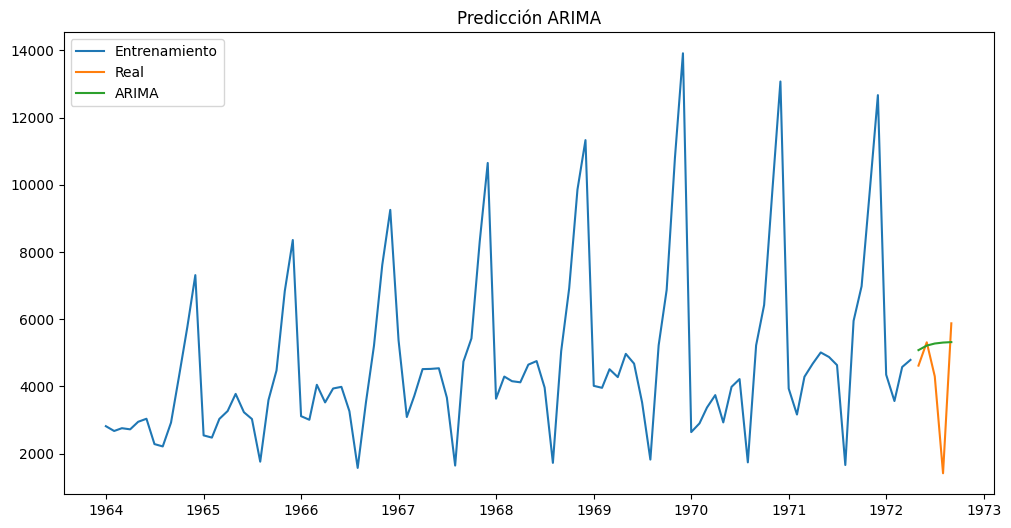

In [8]:
# Dividir en entrenamiento y prueba
train = df['Sales'][:100]
test = df['Sales'][100:]

# Ajustar modelo
model_arima = ARIMA(train, order=(1,1,1))  # puedes ajustar el orden
result_arima = model_arima.fit()

# Predicción
forecast_arima = result_arima.forecast(steps=len(test))
rmse_arima = sqrt(mean_squared_error(test, forecast_arima))
print("ARIMA RMSE:", rmse_arima)

# Gráfica
plt.figure(figsize=(12, 6))
plt.plot(train, label='Entrenamiento')
plt.plot(test.index, test, label='Real')
plt.plot(test.index, forecast_arima, label='ARIMA')
plt.title("Predicción ARIMA")
plt.legend()
plt.show()


Modelo Prophet

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpgum30gpb/2yp1ety_.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpgum30gpb/gksdkgkk.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=7824', 'data', 'file=/tmp/tmpgum30gpb/2yp1ety_.json', 'init=/tmp/tmpgum30gpb/gksdkgkk.json', 'output', 'file=/tmp/tmpgum30gpb/prophet_model664_dtic/prophet_model-20250618213608.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
21:36:08 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
21:36:08 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.11/dist-packages/p

Prophet RMSE: 589.809764991658


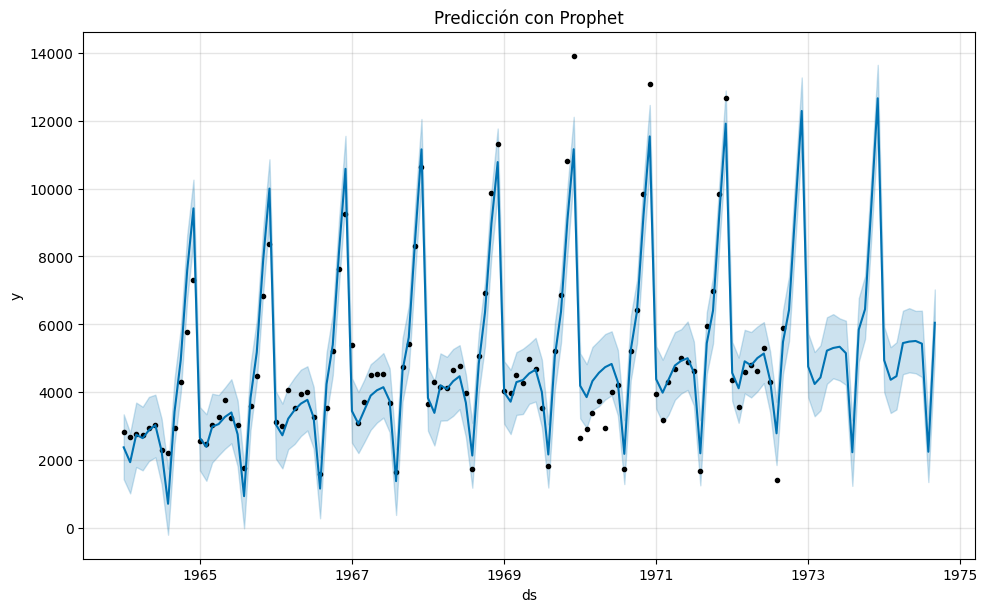

In [10]:
df_prophet = df.reset_index().rename(columns={"Month": "ds", "Sales": "y"})

model_prophet = Prophet()
model_prophet.fit(df_prophet)

future = model_prophet.make_future_dataframe(periods=24, freq='M')
forecast = model_prophet.predict(future)

real = df_prophet.set_index("ds")['y']
predicted = forecast.set_index("ds")['yhat'][-24:]

rmse_prophet = sqrt(mean_squared_error(real[-24:], predicted))
print("Prophet RMSE:", rmse_prophet)

model_prophet.plot(forecast)
plt.title("Predicción con Prophet")
plt.show()


Modelo LSTM

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 138ms/step - loss: 0.1170 - val_loss: 0.1293
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0489 - val_loss: 0.0851
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0428 - val_loss: 0.0845
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0382 - val_loss: 0.0936
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0369 - val_loss: 0.0965
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0373 - val_loss: 0.0953
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0494 - val_loss: 0.0944
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0492 - val_loss: 0.0939
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0393 - val_loss: 0.0969
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0506 - val_loss: 0.0918
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0344 - val_loss: 0.0911
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0450 - val_l

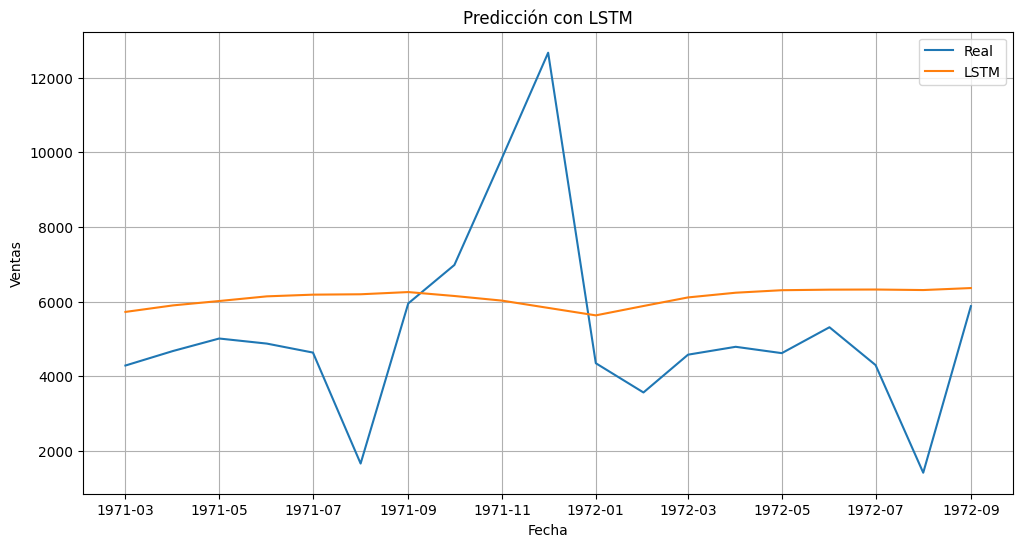

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from math import sqrt
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping

# Cargar los datos
df = pd.read_csv("monthly_champagne_sales.csv")
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# Escalar los datos
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['Sales']])

# Preparar secuencias para LSTM
look_back = 12
X, y = [], []
for i in range(look_back, len(scaled_data)):
    X.append(scaled_data[i-look_back:i, 0])
    y.append(scaled_data[i, 0])
X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Dividir en entrenamiento y prueba
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Modelo LSTM mejorado
model_lstm = Sequential()
model_lstm.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model_lstm.add(Dropout(0.2))
model_lstm.add(LSTM(units=50, return_sequences=False))
model_lstm.add(Dropout(0.2))
model_lstm.add(Dense(1))

# Compilar y entrenar
model_lstm.compile(optimizer='adam', loss='mean_squared_error')
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_lstm.fit(X_train, y_train, validation_split=0.1, epochs=100, batch_size=16, callbacks=[early_stop], verbose=1)

# Predicción
predicted_lstm = model_lstm.predict(X_test)
predicted_lstm = scaler.inverse_transform(predicted_lstm.reshape(-1, 1))
y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1))

# RMSE
rmse_lstm = sqrt(mean_squared_error(y_test_original, predicted_lstm))
print("LSTM RMSE:", rmse_lstm)

# Visualización
plt.figure(figsize=(12, 6))
plt.plot(df.index[-len(y_test_original):], y_test_original, label='Real')
plt.plot(df.index[-len(predicted_lstm):], predicted_lstm, label='LSTM')
plt.title("Predicción con LSTM")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid(True)
plt.show()

df['month'] = df.index.month
df['sin_month'] = np.sin(2 * np.pi * df['month']/12)
df['cos_month'] = np.cos(2 * np.pi * df['month']/12)



Conclusiones Finales

Durante esta actividad se evaluaron distintos modelos para abordar un problema de pronóstico de series de tiempo aplicado a las ventas mensuales de champaña. Se implementaron cuatro enfoques: el modelo ingenuo, ARIMA, Prophet y una red neuronal del tipo LSTM. El desempeño de cada modelo se comparó utilizando la métrica RMSE (raíz cuadrada del error cuadrático medio).

Comparación de modelos
Modelo ingenuo
Funcionó como línea base de comparación, replicando el valor del mes anterior como predicción. Aunque es una referencia útil, su capacidad predictiva fue limitada, especialmente ante la presencia de estacionalidad y variaciones abruptas en los datos.

Modelo ARIMA
Ofreció un ajuste razonable a la tendencia general de la serie. Sin embargo, su capacidad para capturar patrones estacionales complejos se mantuvo limitada, a menos que se configure explícitamente con componentes estacionales, lo cual puede requerir prueba y error.

Modelo Prophet (Meta/Facebook)
Se destacó por su facilidad de uso y por capturar automáticamente la estacionalidad anual presente en la serie. Mostró un buen desempeño frente a los picos cíclicos, como los ocurridos en los meses de diciembre. Resulta especialmente útil cuando se trabaja con fechas y eventos repetitivos en el tiempo.

Modelo LSTM (Red Neuronal Recurrente)
A pesar de ser una técnica avanzada basada en aprendizaje profundo, en este caso no logró capturar correctamente los patrones estacionales ni los picos de la serie. Las predicciones resultaron suavizadas y poco sensibles a las variaciones reales. Esto puede deberse a la falta de variables adicionales que aporten contexto (por ejemplo, codificación del mes), a un tamaño de muestra limitado, o a una arquitectura aún poco profunda para la complejidad de la serie.

Conclusión general
Entre los modelos evaluados, Prophet presentó el mejor equilibrio entre precisión y facilidad de implementación para una serie temporal con estacionalidad marcada. Su capacidad para modelar patrones estacionales de forma automática lo convierte en una opción adecuada para este tipo de problemas.

En contraste, aunque LSTM es un modelo poderoso, requiere una arquitectura más robusta, más datos y un diseño más elaborado para ofrecer mejoras sustanciales en este tipo de series. Por lo tanto, para problemas de predicción mensual con patrones estacionales bien definidos y conjuntos de datos moderados, Prophet o ARIMA suelen ser opciones más eficientes y prácticas que modelos basados en aprendizaje profundo.

## **<<< Fin de la Actividad de la Semana - Pronósticos y Series de Tiempo >>>**